In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as   mcolors
from datataking import search_datadict_miyamura
from scipy import interpolate
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit

cd = "CDY160"
data_path = f"D:\\K_Sunada\\result\\{cd}\\rx\\"

readout_lo_freq = 9.38

# symmetrical shape

In [52]:
name_dict = dict(
    data0 = dict(amp=0.05, date="2024-06-24", acquire_time="121452", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data05 = dict(amp=0.075, date="2024-06-24", acquire_time="125512", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data1 = dict(amp=0.1, date="2024-06-19", acquire_time="230316", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data2 = dict(amp=0.125, date="2024-06-20", acquire_time="075518", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data3 = dict(amp=0.15, date="2024-06-19", acquire_time="233250", params=dict(fit_start=30, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data4 = dict(amp=0.175, date="2024-06-20", acquire_time="082453", params=dict(fit_start=30, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data5 = dict(amp=0.2, date="2024-06-20", acquire_time="000224", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data6 = dict(amp=0.225, date="2024-06-20", acquire_time="092259", params=dict(fit_start=30, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    # data7 = dict(amp=0.25, date="2024-06-20", acquire_time="010034", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data8 = dict(amp=0.3, date="2024-06-20", acquire_time="012943", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data9 = dict(amp=0.35, date="2024-06-20", acquire_time="015822", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data10 = dict(amp=0.4, date="2024-06-20", acquire_time="022658", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data8 = dict(amp=0.8, date="2024-06-01", acquire_time="131449", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # # data85 = dict(amp=0.85, date="2023-12-27", acquire_time="223440", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data9 = dict(amp=0.9, date="2024-06-01", acquire_time="134354", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data10 = dict(amp=1.0, date="2024-06-01", acquire_time="141231", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data11 = dict(amp=1.1, date="2024-05-30", acquire_time="043124", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data12 = dict(amp=1.2, date="2024-05-13", acquire_time="223813", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data125 = dict(amp=1.25, date="2023-12-27", acquire_time="041444", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data13 = dict(amp=1.075, date="2024-2-20", acquire_time="203046", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data14 = dict(amp=1.1, date="2023-12-27", acquire_time="102535", params=dict(fit_start=50, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data15 = dict(amp=1.125, date="2023-12-27", acquire_time="101913", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data15 = dict(amp=1.2, date="2023-12-27", acquire_time="035436", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data16 = dict(amp=1.3, date="2024-2-20", acquire_time="195024", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data17 = dict(amp=1.4, date="2023-12-27", acquire_time="045145", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data18 = dict(amp=1.45, date="2023-12-27", acquire_time="052020", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data181 = dict(amp=1.48, date="2023-12-27", acquire_time="054855", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data182 = dict(amp=1.49, date="2023-12-27", acquire_time="061732", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data19 = dict(amp=1.3, date="2023-12-27", acquire_time="111410", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
)

# Generating Control Pulses

In [53]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)
# 2024-2-20 janakute 2024-02-20 (miyamura)

0.05 2024-06-24 121452
0.075 2024-06-24 125512
0.1 2024-06-19 230316
0.125 2024-06-20 075518
0.15 2024-06-19 233250
0.175 2024-06-20 082453
0.2 2024-06-20 000224
0.225 2024-06-20 092259


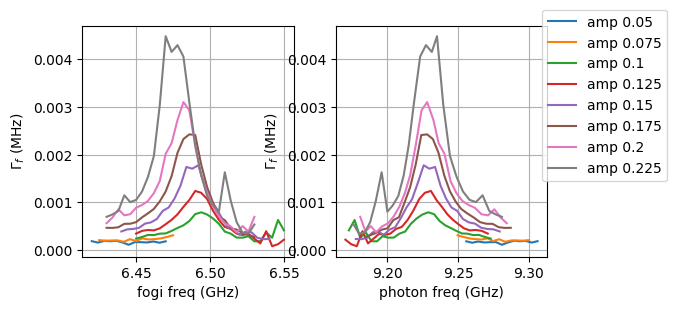

{'a0': 0, 'a2': 0.018812118964545155, 'a4': 0.006639672383731199, 'a6': 3.6620484422655863e-11, 'a8': 2.1075763356748212e-10, 'a10': 0.05524029954635967}


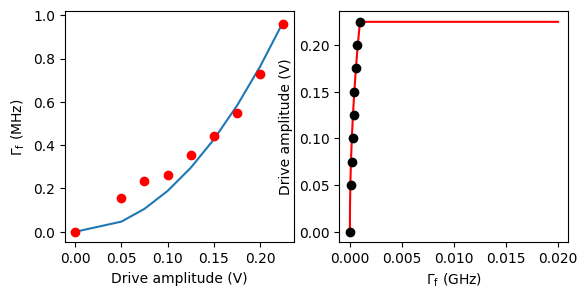

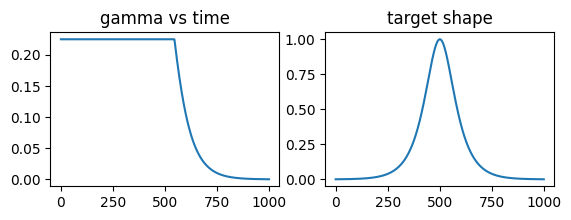

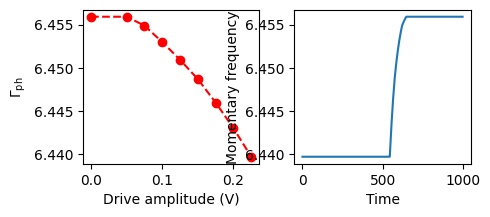

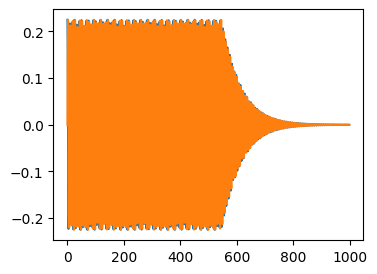

In [54]:
form = "sech"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.27

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(6.32, target_freq, duration, const=const, form=form, tr=True)

## save

In [55]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T

for target_freq in [9.266]:
    control_pulse = dataobj.generate_control_pulse(6.32, target_freq, duration, const=const, form=form, plot=False, tr=True)
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd])
        writer.save_text("target_shape.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.02055287369527381, 'a4': 9.46924050282405e-09, 'a6': 4.404254738687996e-12, 'a8': 5.423514788382988e-07, 'a10': 116.60299281773983}


# Photon shaping analysis

In [29]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=9.266, date="2024-06-24", acquire_time="135623"),
    # data1 = dict(target_freq=10.30, date="2024-06-01", acquire_time="185049"),
    # data2 = dict(target_freq=10.32, date="2024-06-01", acquire_time="185739"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),
    # data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="112646"),
)

In [30]:
def fit_waveform(time, data, x0=[2e-3,600], get_center=False, curve='gaussian', **kwargs):
    if curve=='gaussian':
        func = lambda x: x[0]*np.exp(-((time-x[1])/kwargs['sigma'])**2/2)
        cost_func = lambda x: np.linalg.norm(x[0]*np.exp(-((time-x[1])/kwargs['sigma'])**2/2) - data)
    elif curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="raisedcos":
        func = lambda x: x[0]*np.sin(np.pi*(time-x[1])/kwargs['T'])**2*(time<=kwargs['T']+x[1])*(x[1]<=time)
        cost_func = lambda x: np.linalg.norm(x[0]*np.sin(np.pi*(time-x[1])/kwargs['T'])**2*(time<=kwargs['T']+x[1])*(x[1]<=time) - data)
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

def IQ_sym_(wave,time,start=0,stop=3000):
    wave_rev = np.flip(wave)
    norm=np.sum(np.abs(wave)**2)**2
    m=0
    c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = wave*wave_rev_i
        mult_sum=np.sum(mult)
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    # plt.plot(np.arange(len(wave)), c)
    return m/norm

def target_overlap(wave, time):
    wave_rev = np.flip(wave)
    target = 1 / np.cosh(const * (time-time[-1]/2))
    norm = np.sum(np.abs(wave)**2) * (time[1] - time[0])
    norm_target  =np.sum(np.abs(target)**2) * (time[1] - time[0])
    m=0 ;c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = target*wave_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    return m / norm / norm_target

symmetry 0.7993003244326938, overlap 0.671176345565241


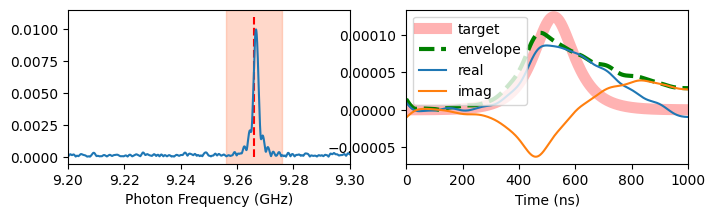

In [31]:
passing_band = 0.01
duration=1000
cd = "CDY160"
data_path = f"D:\\K_Sunada\\result\\{cd}\\rx"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.2, 9.3)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time)}")
plt.legend()


orignal substraction

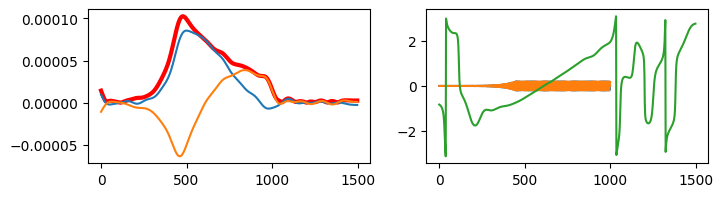

In [32]:
# original
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

corrected photon shaping

In [50]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 1.25e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=9.266, date="2024-06-24", acquire_time="140444"),
    # data1 = dict(target_freq=10.30, date="2024-06-01", acquire_time="191607"),
    # data2 = dict(target_freq=10.32, date="2024-06-01", acquire_time="192256"),
    # data3 = dict(target_freq=10.26, date="2024-05-23", acquire_time=""),
    # data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="145759"),
)


symmetry 0.7832690085649545, overlap 0.9090151220268412


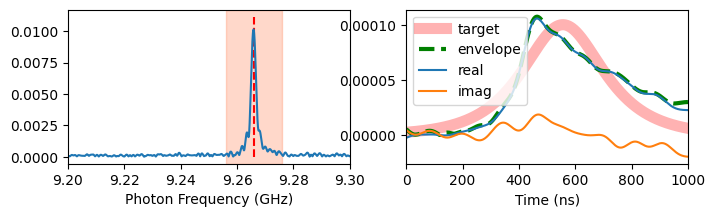

In [51]:
passing_band = 0.01
duration=1000
cd = "CDY160"
data_path = f"D:\\K_Sunada\\result\\{cd}\\rx"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.2, 9.3)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time)}")
plt.legend()


Phase subtraction for abs

In [56]:
result_dict = dict(
    data0 = dict(target_freq=9.266, date="2024-06-24", acquire_time="135623"),
)

In [57]:
date="2024-06-24"
time_set = ["141409"] #control_pulse waveform

135623


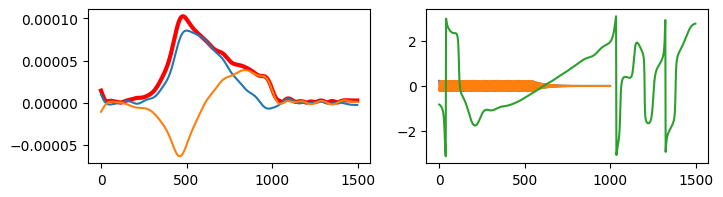

In [58]:
# time reverse
id = 0
data_path = f"D:\\K_Sunada\\result\\{cd}\\rx"

import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    print(v["acquire_time"])
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    # target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    # idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    # ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=time_set[id])
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction[::-1])
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n")
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)

# othogonal mode

In [ ]:
form = "anti_sech"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 10.3

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.32, target_freq, duration, const=const, form=form)

In [ ]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T

for target_freq in [10.28, 10.3, 10.32]:
    control_pulse = dataobj.generate_control_pulse(5.32, target_freq, duration, const=const, form=form, plot=False)
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, "D:\\K_Sunada\\result\\control_pulses", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd])
        writer.save_text("target_shape.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

# LO stability

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-10-04", acquire_time="102837")
time = np.unique(datadict["time"]["values"])
waveforms = datadict["waveform"]["values"]
target_freq = 10.51
for waveform in waveforms:
    signal = lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.005, 0.03, 0.5, 90)
    plt.plot(np.angle(signal))
# plt.ylim(-np.pi, -2); plt.xlim(100, 400)
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-04", acquire_time="155150")
time = np.unique(datadict["time"]["values"])
waveforms = datadict["waveform"]["values"]
target_freq = 10.51
for waveform in waveforms:
    signal = lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.005, 0.03, 0.5, 90)
    plt.plot(np.angle(signal))
plt.ylim(-np.pi, -2); plt.xlim(100, 400)
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-04", acquire_time="155457")
time = np.unique(datadict["time"]["values"])
waveforms = datadict["waveform"]["values"]
target_freq = 10.51
for waveform in waveforms:
    signal = lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.005, 0.03, 0.5, 90)
    plt.plot(np.angle(signal))
plt.ylim(-np.pi, -2); plt.xlim(100, 400)
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-04", acquire_time="155726")
time = np.unique(datadict["time"]["values"])
waveforms = datadict["waveform"]["values"]
target_freq = 10.51
for waveform in waveforms:
    signal = lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.005, 0.03, 0.5, 90)
    plt.plot(np.angle(signal))
plt.ylim(-np.pi, -2); plt.xlim(100, 400)
plt.show()

# Coherent state pulse mode

In [ ]:

fig = plt.figure(figsize=(8, 2))
ax = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
target_freq = 10.04
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="001327")
time = datadict["time"]["values"].ravel()
waveform = datadict["waveform"]["values"].ravel()
time, waveform = start_stop(time, waveform, 0, duration)
phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
# print(readout_lo_freq-target_freq)
xfft, fourier = fourier_tr_padding(time, waveform)
xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
photon_freq = readout_lo_freq + xfft
ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
ax.plot(photon_freq, np.abs(fourier))
ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
ax.set_xlim(10.0, 10.1)
ax.set_xlabel("Photon Frequency (GHz)")

signal = 2 * lowpass(time, 
                    waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                    passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
ax2.plot(time, res, "r-", lw=3, label="target", alpha=0.3)
ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
ax2.plot(time, signal.real, label="real")
ax2.plot(time, signal.imag, label="imag")
ax2.set_xlabel("Time (ns)")
ax2.set_xlim(0, 1000)
print(f"symmetry {IQ_sym_(signal, time)}")

### 10.04

In [ ]:
target_freq = 10.04
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="004238")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

### 10.05

In [ ]:
target_freq = 10.05
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="005245")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

### 10.06

In [ ]:
target_freq = 10.06
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="005552")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

### 10.07

In [ ]:
target_freq = 10.07
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="005744")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

### 10.08

In [ ]:
target_freq = 10.08
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="005933")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

In [ ]:
1 / 50.5 * 1e3 / 2 / np.pi

In [ ]:
1 / 4 / 2 / np.pi * 1e3